In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
df = pd.read_csv(os.path.join(os.getcwd(),'Data/master_data.csv'))

In [3]:
def check_moneyness(df_trade, moneyness,expiry_in_months):
    
    idx = (df_trade['AbsMoneyness'] - moneyness).abs().idxmin()
    
    
    mn = df_trade.AbsMoneyness.loc[idx]
    df_trade = df_trade[(df_trade.Month_To_Expiry==expiry_in_months)&(df_trade.AbsMoneyness==mn)]
    return df_trade


In [4]:
def extract_data(expiry_in_months = 3,moneyness = 90,callput = 'c',hold=1):
    dates = np.sort(df[df.Symbol == 'EV'].TradeDate.unique())

    opt_list = []
    for i,date in enumerate(dates):
     
        if i+hold<=len(dates)-1:
            last_trade = dates[i+hold]
        else:
            last_trade = dates[-1]
        d1 = pd.to_datetime(date, format="%Y%m%d")
        d2 = pd.to_datetime(last_trade, format="%Y%m%d")
        days = (d2 - d1).days
        df_trade = df[(df.TradeDate==date)&(df.CallPut ==callput)&(df.days_to_expiry>=days)]

        if df_trade[(df_trade.Month_To_Expiry==expiry_in_months)&(df_trade.Moneyness==moneyness)].shape[0]>=1:
            df_trade = df_trade[(df_trade.Month_To_Expiry==expiry_in_months)&(df_trade.Moneyness==moneyness)]

        elif df_trade[(df_trade.Month_To_Expiry==expiry_in_months)].shape[0]>=1:
            df_trade = check_moneyness(df_trade, moneyness,expiry_in_months)
            

        elif df_trade[(df_trade.Month_To_Expiry==expiry_in_months)].shape[0]<1:
            if df_trade[(df_trade.Month_To_Expiry==expiry_in_months+1)].shape[0]>=1:
                min_days_valid = df_trade[(df_trade.Month_To_Expiry==expiry_in_months+1)].days_to_expiry.min()
                if df_trade[(df_trade.Month_To_Expiry==expiry_in_months+1)&(df_trade.days_to_expiry==min_days_valid)
                            &(df_trade.Moneyness==moneyness)].shape[0]>=1:

                    df_trade = df_trade[(df_trade.Month_To_Expiry==expiry_in_months+1)&(df_trade.days_to_expiry==min_days_valid)
                                        &(df_trade.Moneyness==moneyness)]
                else:
                    df_temp = df_trade[(df_trade.Month_To_Expiry==expiry_in_months+1)&(df_trade.days_to_expiry==min_days_valid)]
                    if df_temp.shape[0]>=1:
                        df_trade = check_moneyness(df_temp, moneyness,expiry_in_months+1)

            else :
                df_trade = df[(df.TradeDate==date)&(df.CallPut ==callput)&(df.days_to_expiry<days)&
                              (df.Month_To_Expiry==expiry_in_months)&(df.Moneyness==moneyness)]
                max_days_valid = df_trade[(df_trade.Month_To_Expiry==expiry_in_months)].days_to_expiry.max()
                if df_trade[(df_trade.Month_To_Expiry==expiry_in_months)&(df_trade.days_to_expiry==max_days_valid)
                            &(df_trade.Moneyness==moneyness)].shape[0]>=1:
                    df_trade[(df_trade.Month_To_Expiry==expiry_in_months)&(df_trade.days_to_expiry==max_days_valid)
                            &(df_trade.Moneyness==moneyness)]
                else:
                    df_temp = df_trade[(df_trade.Month_To_Expiry==expiry_in_months)&(df_trade.days_to_expiry==max_days_valid)]
                    if df_temp.shape[0]>=1:
                        df_trade = check_moneyness(df_temp, moneyness,expiry_in_months)
                    

                if df_trade.shape[0]<1:
                    print(f'Data with moneyness={moneyness},{callput} and expiry in {expiry_in_months} months not traded on {date}')
     
        max_oi = df_trade.OpenInterest.max()
        df_trade = df_trade[df_trade.OpenInterest==max_oi]
        if df_trade.shape[0]>1:
            df_trade = pd.DataFrame([df_trade.values[0]], columns=list(df_trade.columns))
        opt_list.append(df_trade[df_trade.OpenInterest==max_oi])


        
    df_opt  = pd.concat(opt_list, ignore_index=True)

    return df_opt

In [5]:
df_opt=extract_data(expiry_in_months=1,callput='c',moneyness=100)

In [6]:
df_opt.tail()

,Ticker,TradeDate,ExpiryDate,CallPut,Strike,Spot,Month_To_Expiry,days_to_expiry,ExpirySpot,AdjExpiry,...,13 weeks coupon equivalent,17 weeks coupon equivalent,26 weeks coupon equivalent,52 weeks coupon equivalent,risk_free_rate_4,risk_free_rate_8,risk_free_rate_13,risk_free_rate_17,risk_free_rate_26,risk_free_rate_52
187,AAPL,20250829,20251003,c,240.0,232.14,2,35,258.02,2025-10-03,...,4.15,4.13,3.99,3.85,3.731199,3.259976,2.849116,2.616105,2.196252,1.581133
188,AAPL,20250930,20251031,c,250.0,254.63,1,31,270.37,2025-10-31,...,3.95,3.93,3.84,3.68,3.580109,3.168371,2.749595,2.529665,2.145439,1.545375
189,AAPL,20251031,20251128,c,280.0,270.37,1,28,278.85,2025-11-28,...,3.82,3.87,3.82,3.71,3.473294,3.100365,2.683556,2.503251,2.138566,1.551779
190,AAPL,20251128,20260102,c,290.0,278.85,2,35,271.01,2026-01-02,...,3.82,3.84,3.78,3.61,3.473294,3.062970,2.683556,2.489958,2.124748,1.530273
191,AAPL,20251231,20260116,c,270.0,271.86,1,16,255.53,2026-01-16,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607


In [7]:
def get_next(x):
    """
    get the next trade date and check if the option was traded in that date"""
    dates = np.sort(df[df.Symbol == 'EV'].TradeDate.unique())
    
    trade_date = x.BotDate
    idx = np.where(dates==trade_date)[0][0]
   
    if idx == len(dates)-1:
        
        return (True,trade_date)
    
    date = dates[idx+1]
    return (date in x.TradeDate,date)
    

In [8]:
def check_for_dates(expiry_in_months=1,callput='c',moneyness=100):   
    df_opt=extract_data(expiry_in_months=expiry_in_months,callput=callput,moneyness=moneyness)
    
    bot = []
    trade_date = []
    strike = []
    expiry = []
    next_date =[]
    for i in range(len(df_opt)):
        
        data = df_opt.loc[i]

        bot.append(data.TradeDate)
        strike.append(data.Strike)
        expiry.append(data.ExpiryDate)
        trade_date.append(df[(df.Strike == data.Strike)&(df.ExpiryDate == data.ExpiryDate)&(df.Symbol=='EV')
                            &(df.CallPut ==data.CallPut)&(df.TradeDate>data.TradeDate)].TradeDate.values)
    trade_summary = pd.DataFrame({'BotDate':bot,'TradeDate':trade_date,'Strike':strike,'Expiry':expiry})
    trade_summary['traded_dates'] = trade_summary.apply(lambda x:get_next(x),axis=1)
    trade_summary['Traded'] = trade_summary.traded_dates.apply(lambda x : x[0])
    trade_summary['TradeDate'] = trade_summary.traded_dates.apply(lambda x : x[1])
    trade_summary = trade_summary[trade_summary.Traded==False]
    trade_summary = trade_summary.drop(columns=['traded_dates'])
    return trade_summary
        

In [12]:
data = df_opt.iloc[8]
df[(df.Strike == data.Strike)&(df.Symbol=='EV')&(df.CallPut ==data.CallPut)&(df.TradeDate>data.TradeDate)]

,Ticker,TradeDate,ExpiryDate,CallPut,Strike,Spot,Month_To_Expiry,days_to_expiry,ExpirySpot,AdjExpiry,...,13 weeks coupon equivalent,17 weeks coupon equivalent,26 weeks coupon equivalent,52 weeks coupon equivalent,risk_free_rate_4,risk_free_rate_8,risk_free_rate_13,risk_free_rate_17,risk_free_rate_26,risk_free_rate_52
8947,AAPL,20101029,20130119,c,290.0,300.98,27,813,500.00,2013-01-18,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9068,AAPL,20101029,20110416,c,290.0,300.98,6,169,327.46,2011-04-15,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9075,AAPL,20101029,20120121,c,290.0,300.98,15,449,420.30,2012-01-20,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9114,AAPL,20101029,20101105,c,290.0,300.98,1,7,317.13,2010-11-05,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9120,AAPL,20101029,20101029,c,290.0,300.98,0,0,300.98,2010-10-29,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
682593,AAPL,20251231,20280121,c,290.0,271.86,25,751,271.86,2028-01-21,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607
682680,AAPL,20251231,20280317,c,290.0,271.86,27,807,271.86,2028-03-17,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607
682997,AAPL,20251231,20270115,c,290.0,271.86,13,380,271.86,2027-01-15,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607
683049,AAPL,20251231,20270617,c,290.0,271.86,18,533,271.86,2027-06-17,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607


In [13]:
df[(df.Strike == data.Strike)&(df.Symbol=='EV')&(df.CallPut ==data.CallPut)&(df.TradeDate>data.TradeDate)]


,Ticker,TradeDate,ExpiryDate,CallPut,Strike,Spot,Month_To_Expiry,days_to_expiry,ExpirySpot,AdjExpiry,...,13 weeks coupon equivalent,17 weeks coupon equivalent,26 weeks coupon equivalent,52 weeks coupon equivalent,risk_free_rate_4,risk_free_rate_8,risk_free_rate_13,risk_free_rate_17,risk_free_rate_26,risk_free_rate_52
8947,AAPL,20101029,20130119,c,290.0,300.98,27,813,500.00,2013-01-18,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9068,AAPL,20101029,20110416,c,290.0,300.98,6,169,327.46,2011-04-15,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9075,AAPL,20101029,20120121,c,290.0,300.98,15,449,420.30,2012-01-20,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9114,AAPL,20101029,20101105,c,290.0,300.98,1,7,317.13,2010-11-05,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9120,AAPL,20101029,20101029,c,290.0,300.98,0,0,300.98,2010-10-29,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
682593,AAPL,20251231,20280121,c,290.0,271.86,25,751,271.86,2028-01-21,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607
682680,AAPL,20251231,20280317,c,290.0,271.86,27,807,271.86,2028-03-17,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607
682997,AAPL,20251231,20270115,c,290.0,271.86,13,380,271.86,2027-01-15,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607
683049,AAPL,20251231,20270617,c,290.0,271.86,18,533,271.86,2027-06-17,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607


In [14]:
df[(df.Strike == data.Strike)&(df.Symbol=='EV')&(df.CallPut ==data.CallPut)&(df.TradeDate>data.TradeDate)]

,Ticker,TradeDate,ExpiryDate,CallPut,Strike,Spot,Month_To_Expiry,days_to_expiry,ExpirySpot,AdjExpiry,...,13 weeks coupon equivalent,17 weeks coupon equivalent,26 weeks coupon equivalent,52 weeks coupon equivalent,risk_free_rate_4,risk_free_rate_8,risk_free_rate_13,risk_free_rate_17,risk_free_rate_26,risk_free_rate_52
8947,AAPL,20101029,20130119,c,290.0,300.98,27,813,500.00,2013-01-18,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9068,AAPL,20101029,20110416,c,290.0,300.98,6,169,327.46,2011-04-15,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9075,AAPL,20101029,20120121,c,290.0,300.98,15,449,420.30,2012-01-20,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9114,AAPL,20101029,20101105,c,290.0,300.98,1,7,317.13,2010-11-05,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
9120,AAPL,20101029,20101029,c,290.0,300.98,0,0,300.98,2010-10-29,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.118240,NaN,0.163178,0.190667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
682593,AAPL,20251231,20280121,c,290.0,271.86,25,751,271.86,2028-01-21,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607
682680,AAPL,20251231,20280317,c,290.0,271.86,27,807,271.86,2028-03-17,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607
682997,AAPL,20251231,20270115,c,290.0,271.86,13,380,271.86,2027-01-15,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607
683049,AAPL,20251231,20270617,c,290.0,271.86,18,533,271.86,2027-06-17,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607


In [15]:
df[(df.Strike == data.Strike)&(df.ExpiryDate == data.ExpiryDate)&(df.Symbol=='EV')
                            &(df.CallPut ==data.CallPut)&(df.TradeDate>data.TradeDate)].TradeDate.values

array([20101029])

In [16]:
data.ExpiryDate

np.int64(20101120)

In [17]:
data = df_opt.iloc[8]

In [18]:
check_for_dates(expiry_in_months=3,callput='c',moneyness=90)

Data with moneyness=90,c and expiry in 3 months not traded on 20100226
Data with moneyness=90,c and expiry in 3 months not traded on 20100528
Data with moneyness=90,c and expiry in 3 months not traded on 20100831


,BotDate,TradeDate,Strike,Expiry,Traded
6,20101029,20101130,280.0,20110122,False
8,20101231,20110131,300.0,20110318,False
49,20140530,20140630,590.0,20140816,False
123,20200731,20200831,400.0,20201016,False


In [19]:
trade_dict = {'100_1m_c':(1,'c',100),'100_1m_p':(1,'p',100),'100_3m_c':(3,'c',100),'100_3m_p':(3,'p',100),'90_3m_p':(3,'p',90),
              '110_3m_c':(3,'c',110)}
for k,v in trade_dict.items():

    trade_dict[k] = check_for_dates(expiry_in_months=v[0],callput=v[1],moneyness=v[2])




Data with moneyness=100,c and expiry in 3 months not traded on 20100226
Data with moneyness=100,c and expiry in 3 months not traded on 20100528
Data with moneyness=100,c and expiry in 3 months not traded on 20100831
Data with moneyness=100,p and expiry in 3 months not traded on 20100226
Data with moneyness=100,p and expiry in 3 months not traded on 20100528
Data with moneyness=100,p and expiry in 3 months not traded on 20100831
Data with moneyness=90,p and expiry in 3 months not traded on 20100226
Data with moneyness=90,p and expiry in 3 months not traded on 20100528
Data with moneyness=90,p and expiry in 3 months not traded on 20100831
Data with moneyness=110,c and expiry in 3 months not traded on 20100226
Data with moneyness=110,c and expiry in 3 months not traded on 20100528
Data with moneyness=110,c and expiry in 3 months not traded on 20100831


In [20]:
trade_dict['100_1m_p']

,BotDate,TradeDate,Strike,Expiry,Traded
9,20101029,20101130,300.0,20101218,False
11,20101231,20110131,320.0,20110218,False
52,20140530,20140630,615.0,20140703,False
126,20200731,20200831,405.0,20200904,False


In [21]:
trade_dict['90_3m_p']

,BotDate,TradeDate,Strike,Expiry,Traded
6,20101029,20101130,270.0,20110122,False
8,20101231,20110131,300.0,20110318,False
49,20140530,20140630,540.0,20140816,False
123,20200731,20200831,375.0,20201016,False


In [22]:
df[(df.TradeDate==20101029)&(df.Moneyness==90)&(df.CallPut =="p")&(df.Month_To_Expiry==3)]

,Ticker,TradeDate,ExpiryDate,CallPut,Strike,Spot,Month_To_Expiry,days_to_expiry,ExpirySpot,AdjExpiry,...,13 weeks coupon equivalent,17 weeks coupon equivalent,26 weeks coupon equivalent,52 weeks coupon equivalent,risk_free_rate_4,risk_free_rate_8,risk_free_rate_13,risk_free_rate_17,risk_free_rate_26,risk_free_rate_52
8694,AAPL,20101029,20110122,p,270.0,300.98,3,85,326.72,2011-01-21,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.11824,NaN,0.163178,0.190667
8695,AAPL,20101029,20110122,p,260.0,300.98,3,85,326.72,2011-01-21,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.11824,NaN,0.163178,0.190667
8739,AAPL,20101029,20110122,p,280.0,300.98,3,85,326.72,2011-01-21,...,0.12,NaN,0.17,0.21,0.139254,NaN,0.11824,NaN,0.163178,0.190667


In [23]:
df[(df.ExpiryDate==20140816)&(df.CallPut =="p")&(df.Strike==540)]

,Ticker,TradeDate,ExpiryDate,CallPut,Strike,Spot,Month_To_Expiry,days_to_expiry,ExpirySpot,AdjExpiry,...,13 weeks coupon equivalent,17 weeks coupon equivalent,26 weeks coupon equivalent,52 weeks coupon equivalent,risk_free_rate_4,risk_free_rate_8,risk_free_rate_13,risk_free_rate_17,risk_free_rate_26,risk_free_rate_52
168508,AAPL,20140424,20140816,p,540.0,567.77,4,114,97.98,2014-08-15,...,0.01,NaN,0.04,0.09,0.000000,NaN,0.009988,NaN,0.039606,0.086188
170399,AAPL,20140430,20140816,p,540.0,590.09,4,108,97.98,2014-08-15,...,0.03,NaN,0.05,0.11,0.019985,NaN,0.029888,NaN,0.049387,0.104374
172506,AAPL,20140515,20140816,p,540.0,588.82,3,93,97.98,2014-08-15,...,0.03,NaN,0.05,0.08,0.009996,NaN,0.029888,NaN,0.049387,0.076969
176414,AAPL,20140530,20140816,p,540.0,633.00,3,78,97.98,2014-08-15,...,0.04,NaN,0.06,0.10,0.049904,NaN,0.039802,NaN,0.059120,0.095322


In [24]:
df[(df.ExpiryDate==20140816)&(df.CallPut =="p")&(df.Strike==77.14)]

,Ticker,TradeDate,ExpiryDate,CallPut,Strike,Spot,Month_To_Expiry,days_to_expiry,ExpirySpot,AdjExpiry,...,13 weeks coupon equivalent,17 weeks coupon equivalent,26 weeks coupon equivalent,52 weeks coupon equivalent,risk_free_rate_4,risk_free_rate_8,risk_free_rate_13,risk_free_rate_17,risk_free_rate_26,risk_free_rate_52
177390,AAPL,20140619,20140816,p,77.14,91.86,2,58,97.98,2014-08-15,...,0.02,NaN,0.05,0.08,0.009996,NaN,0.019950,NaN,0.049387,0.076969
180024,AAPL,20140630,20140816,p,77.14,92.93,2,47,97.98,2014-08-15,...,0.04,NaN,0.07,0.11,0.019985,NaN,0.039802,NaN,0.068806,0.104374
181561,AAPL,20140724,20140816,p,77.14,97.03,1,23,97.98,2014-08-15,...,0.03,NaN,0.06,0.11,0.039939,NaN,0.029888,NaN,0.059120,0.104374
184045,AAPL,20140731,20140816,p,77.14,95.60,1,16,97.98,2014-08-15,...,0.03,NaN,0.05,0.11,0.009996,NaN,0.029888,NaN,0.049387,0.104374
184937,AAPL,20140814,20140816,p,77.14,97.50,0,2,97.98,2014-08-15,...,0.04,NaN,0.06,0.09,0.039939,NaN,0.039802,NaN,0.059120,0.086188


In [25]:
df_opt.tail()

,Ticker,TradeDate,ExpiryDate,CallPut,Strike,Spot,Month_To_Expiry,days_to_expiry,ExpirySpot,AdjExpiry,...,13 weeks coupon equivalent,17 weeks coupon equivalent,26 weeks coupon equivalent,52 weeks coupon equivalent,risk_free_rate_4,risk_free_rate_8,risk_free_rate_13,risk_free_rate_17,risk_free_rate_26,risk_free_rate_52
187,AAPL,20250829,20251003,c,240.0,232.14,2,35,258.02,2025-10-03,...,4.15,4.13,3.99,3.85,3.731199,3.259976,2.849116,2.616105,2.196252,1.581133
188,AAPL,20250930,20251031,c,250.0,254.63,1,31,270.37,2025-10-31,...,3.95,3.93,3.84,3.68,3.580109,3.168371,2.749595,2.529665,2.145439,1.545375
189,AAPL,20251031,20251128,c,280.0,270.37,1,28,278.85,2025-11-28,...,3.82,3.87,3.82,3.71,3.473294,3.100365,2.683556,2.503251,2.138566,1.551779
190,AAPL,20251128,20260102,c,290.0,278.85,2,35,271.01,2026-01-02,...,3.82,3.84,3.78,3.61,3.473294,3.062970,2.683556,2.489958,2.124748,1.530273
191,AAPL,20251231,20260116,c,270.0,271.86,1,16,255.53,2026-01-16,...,3.65,3.64,3.61,3.48,3.217997,2.898399,2.595524,2.399834,2.064935,1.501607


In [26]:
df[(df.ExpiryDate ==20100417)&(df.CallPut=='c')&(df.Strike==180)&(df.Symbol=='EV')]

,Ticker,TradeDate,ExpiryDate,CallPut,Strike,Spot,Month_To_Expiry,days_to_expiry,ExpirySpot,AdjExpiry,...,13 weeks coupon equivalent,17 weeks coupon equivalent,26 weeks coupon equivalent,52 weeks coupon equivalent,risk_free_rate_4,risk_free_rate_8,risk_free_rate_13,risk_free_rate_17,risk_free_rate_26,risk_free_rate_52
753,AAPL,20100129,20100417,c,180.0,192.06,3,78,247.4,2010-04-16,...,0.08,NaN,0.15,0.28,0.019985,NaN,0.079213,NaN,0.144655,0.246937
1346,AAPL,20100226,20100417,c,180.0,204.62,2,50,247.4,2010-04-16,...,0.13,NaN,0.19,0.30,0.089691,NaN,0.127938,NaN,0.181531,0.262451
2426,AAPL,20100331,20100417,c,180.0,235.00,1,17,247.4,2010-04-16,...,0.16,NaN,0.24,0.39,0.149144,NaN,0.156891,NaN,0.226691,0.329437


In [27]:
df[(df.ExpiryDate ==20100417)&(df.CallPut=='c')&(df.Strike==180)&(df.Symbol=='EV')].BidPrice


753     20.30
1346    26.25
2426    54.90
Name: BidPrice, dtype: float64

In [28]:
def compute_delta_iv(x):
    df_iv = df[(df.ExpiryDate ==x['ExpiryDate'])&(df.CallPut==x['CallPut'])&(df.Strike==x['Strike'])&(df.Symbol=='EV')]
    dates = np.sort(df[df.Symbol == 'EV'].TradeDate.unique())
    idx = np.where(dates==x['TradeDate'])[0][0]
    if dates[idx]== dates[-1]:
        trade_date = dates[idx]
    else:
        trade_date = dates[idx+1]

    if trade_date in df_iv.TradeDate:
        if trade_date == dates[-1]:
            delta_iv = 0
        else:
            delta_iv = df_iv[df_iv.Tradedate == trade_date].IV - x.IV
    

    else:
        delta_iv = 0
    return delta_iv

In [29]:
def compute_pnl(data,hold):
    BotOn=[]
    TradeDate = []
    Exp = []
    StrikeBot = []
    SpotStart = []
    OptPx = []
    OptDelta = []
    Gamma = []
    Vega = []
    Theta = []
    Rho =[]
    SpotPct = []
    OptPnl = []
    df_iv = df[(df.ExpiryDate ==data.ExpiryDate)&(df.CallPut==data.CallPut)&(df.Strike==data.Strike)&(df.Symbol=='EV')]
    dates = np.sort(df[df.Symbol == 'EV'].TradeDate.unique())
    last_trade_date = dates[-1]
    idx = np.where(dates==data['TradeDate'])[0][0]
    
    if data.CallPut == "c":
        multiplyer = 1
    else:
        multiplyer = -1
    flag = 0

    for j in range(hold):
        
        
        if j == 0:
            BotOn.append(data.TradeDate)
            TradeDate.append(dates[idx+j+1])
            Exp.append(int(str(data.ExpiryDate)[:-2]))
            StrikeBot.append(data.Strike)
            SpotStart.append(data.Spot)
            OptPx.append((data.AskPrice+data.BidPrice)/2)
            OptDelta.append(data.Delta)
            Gamma.append(data.Gamma)
            Vega.append(data.Vega)
            Theta.append(data.Theta)
            Rho.append(data.Rho)            
            SpotPct.append((data.NextSpot - data.Spot)/data.Spot)
            
            if TradeDate[-1]< data.ExpiryDate:
                # compute delta iv
                pnl = OptDelta[-1]*(data.NextSpot - data.Spot) + (Gamma[-1]/2)*(data.NextSpot - data.Spot)**2 +Theta[-1]*(1/12) + Vega[-1]*data.IV 
            
            else:
                flag =1
                pnl = max(multiplyer*(data.ExpirySpot-StrikeBot),0)-OptPx[-1]
            OptPnl.append(pnl)

        else: 
            if dates[idx+j] in df_iv.TradeDate:
                BotOn.append(data.TradeDate)
                TradeDate.append(dates[idx+j+1])
                Exp.append(int(str(data.ExpiryDate)[:-2]))
                StrikeBot.append(data.Strike)
                SpotStart.append(data.Spot)
                current_data = df_iv[df_iv.TradeDate==dates[idx+j]]
                OptPx.append((current_data.AskPrice+current_data.BidPrice)/2)
                OptDelta.append(current_data.Delta)
                Gamma(current_data.Gama)
                Vega(current_data.Vega)
                Theta(current_data.Theta)
                Rho(current_data.Rho)
                next_spot = df[df.TradeDate == dates[idx+j+1]].Spot
                spot_change = (next_spot-current_data.Spot)/current_data.Spot
                SpotPct.append(spot_change)
                delta_iv = compute_delta_iv(current_data)
                if TradeDate[-1]<= data.ExpiryDate:
                    pnl = OptDelta[-1]*(next_spot - current_data.Spot) + (Gamma[-1]/2)*(data.NextSpot - data.Spot)**2 +Theta[-1]*(1/12) + Vega[-1]*delta_iv
                else:
                    pnl = max(multiplyer*(data.ExpirtSpot-StrikeBot[-1]),0)-OptPx[-1]
                    flag =1
                OptPnl.append(pnl)
            elif j==hold-1:
                OptPx.append(OptPx[-1])
                OptDelta.append(OptDelta[-1])
                Gamma(Gamma[1])
                Vega(Vega[-1])
                Theta(Theta[-1])
                Rho(Rho[-1])
                SpotPct.append(SpotPct[-1])
                if TradeDate[-1]<= data.ExpiryDate:
                    spot = df.loc[df['TradeDate'] == TradeDate[-1],'Spot'].values[0]
                    pnl = max(multiplyer*(spot-StrikeBot[-1]),0)-OptPx[-1]
                else:
                    pnl = max(multiplyer*(data.ExpirtSpot-StrikeBot[-1]),0)-OptPx[-1]
              
        if TradeDate[-1] == last_trade_date:

            flag =1        


        if flag:
             
             break
                
    pnl_frame = pd.DataFrame({'BotOn':BotOn,'TradeDate':TradeDate,'Exp':Exp,'StrikeBot':StrikeBot,
                              'SpotStart':SpotStart,'OptPx':OptPx,'OptDelta':OptDelta,'Gamma':Gamma,
                              'Theta':Theta,'Rho':Rho,'SpotPct':SpotPct,'OptPnl':OptPnl})
    
    return pnl_frame
                              
       
        




In [ ]:
def gen_options_pnl(moneyness = 100, time_to_expiry = 1,callput = 'p',bot =1,hold = 1, buysell = 'buy',
                    value = 1,sizing = "notional",pct = 1,contract_size =100):
    last_date = np.sort(df[df.Symbol == 'EV'].TradeDate.unique())[-1]
    df_opt=extract_data(expiry_in_months=time_to_expiry,moneyness=moneyness,callput=callput,hold =1)
    df_opt['NextSpot'] = df_opt.Spot.shift(-1)
    df_opt['NextSpot'] = df_opt['NextSpot'].ffill()
    df_opt['IV'] = (df.AskImpliedVolatility + df.BidImpliedVolatility)/2
    
    df_opt['delta_IV'] = df_opt.apply(lambda x:compute_delta_iv(x),axis =1)
   
    option_accumulator = []
    for i in range(0,df_opt.shape[0],bot):
        
        
        data = df_opt.loc[i]
        if data.TradeDate == last_date:
            break
        pnl_frame = compute_pnl(data,hold)
        option_accumulator.append(pnl_frame)
    df_op = pd.concat(option_accumulator, ignore_index=True)
        
    
    if sizing == 'notional':
        df_op['OptPnl'] = (df_op.OptPnl/df_op.SpotStart)*value
    if sizing == 'premium':
        df_op['OptPnl'] = (df_op.OptPnl/df_op.OptPx)*pct/100

    if sizing == 'contracts': 
        df_op['OptPnl'] =df_op.OptPnl*contract_size


    return df_op

    
    

In [31]:
mn_100_3m_p = gen_options_pnl(moneyness=100, time_to_expiry=3)

Data with moneyness=100,p and expiry in 3 months not traded on 20100226
Data with moneyness=100,p and expiry in 3 months not traded on 20100528
Data with moneyness=100,p and expiry in 3 months not traded on 20100831


In [32]:
mn_100_3m_p['wealth'] = 1000*(1 + mn_100_3m_p['OptPnl']).cumprod()
    

In [33]:
if not os.path.exists(os.path.join('c:\\Users\\shyam\\Dp Lrn\\Options','Data','wealth_data')):
    os.mkdir((os.path.join('c:\\Users\\shyam\\Dp Lrn\\Options','Data','wealth_data')))

In [34]:
saving_dir = os.path.join('c:\\Users\\shyam\\Dp Lrn\\Options','Data','wealth_data')

In [35]:
mn_100_3m_p.to_csv(os.path.join(saving_dir,'mn_100_3m_p.csv'))

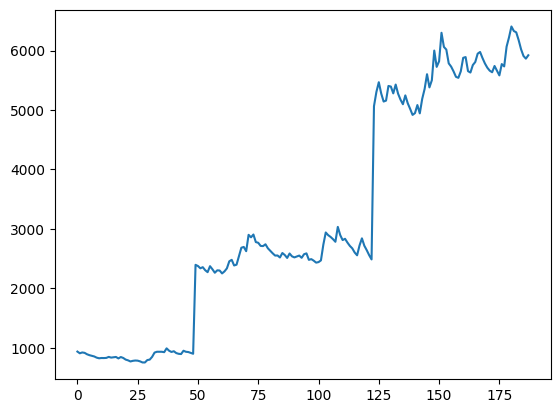

In [36]:
import matplotlib.pyplot as plt
plt.plot(mn_100_3m_p.wealth)

In [37]:
mn_100_3m_c = gen_options_pnl(moneyness=100, time_to_expiry=3,callput='c')
mn_100_3m_c['wealth'] = 1000*(1 + mn_100_3m_c['OptPnl']).cumprod()
    

Data with moneyness=100,c and expiry in 3 months not traded on 20100226
Data with moneyness=100,c and expiry in 3 months not traded on 20100528
Data with moneyness=100,c and expiry in 3 months not traded on 20100831


In [38]:
mn_100_3m_c.to_csv(os.path.join(saving_dir,'mn_100_3m_c.csv'))

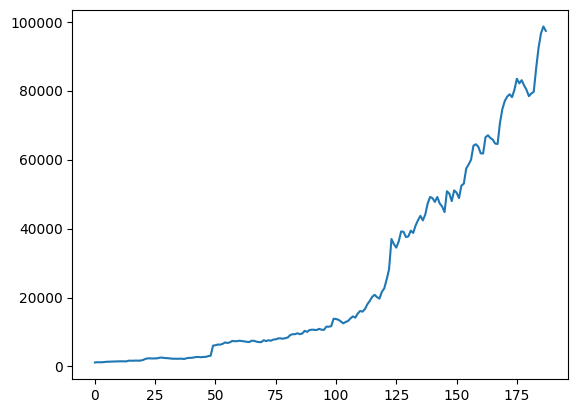

In [39]:
plt.plot(mn_100_3m_c.wealth)

In [51]:
mn_100_3m_c.head()

,BotOn,TradeDate,Exp,StrikeBot,SpotStart,OptPx,OptDelta,Gamma,Theta,Rho,SpotPct,OptPnl,wealth
0,20100129,20100226,201004,200.0,192.06,9.725,0.4404,0.0123,-0.0829,0.1603,0.223576,0.158024,1158.023567
1,20100331,20100430,201007,240.0,235.00,13.150,0.4843,0.0105,-0.0719,0.2980,0.111021,0.069643,1238.671294
2,20100430,20100528,201007,250.0,261.09,22.925,0.6401,0.0089,-0.1051,0.3082,-0.036616,-0.021315,1212.268851
3,20100630,20100730,201010,260.0,251.53,19.625,0.4902,0.0069,-0.1083,0.3068,0.022741,0.012497,1227.418229
4,20100730,20100831,201010,260.0,257.25,14.075,0.5083,0.0106,-0.1014,0.2492,0.103013,0.067440,1310.195512


In [52]:
dates = np.sort(df[df.Symbol == 'EV'].TradeDate.unique())
missing_dates = [date for date in dates if date not in mn_100_3m_c.BotOn.values]



In [53]:
missing_dates

[np.int64(20100226),
 np.int64(20100528),
 np.int64(20100831),
 np.int64(20251231)]

In [40]:
mn_100_1m_p = gen_options_pnl(moneyness=100, time_to_expiry=1)
mn_100_1m_p['wealth'] = 1000*(1 + mn_100_1m_p['OptPnl']).cumprod()

In [55]:
mn_100_1m_p.to_csv(os.path.join(saving_dir,'mn_100_1m_p.csv'))

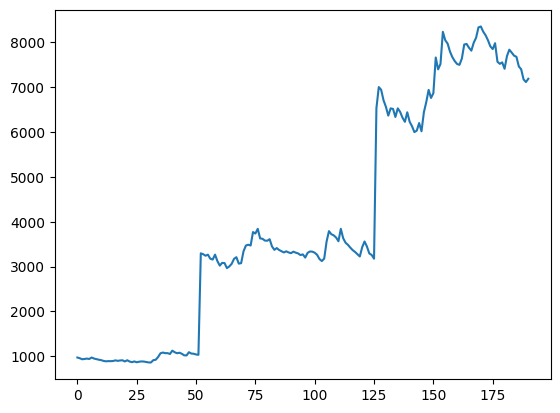

In [54]:
plt.plot(mn_100_1m_p.wealth)

In [48]:
mn_100_1m_c = gen_options_pnl(moneyness=100, time_to_expiry=1,callput='c')
mn_100_1m_c['wealth'] = 1000*(1 + mn_100_1m_c['OptPnl']).cumprod()
    

In [49]:
mn_100_1m_c.to_csv(os.path.join(saving_dir,'mn_100_1m_c.csv'))


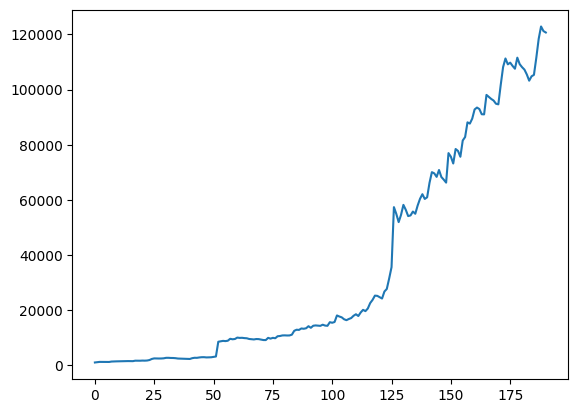

In [50]:
plt.plot(mn_100_1m_c.wealth)

In [51]:
mn_90_1m_p = gen_options_pnl(moneyness=90, time_to_expiry=1)
mn_90_1m_p.shape

(191, 12)

In [52]:
mn_110_1m_c = gen_options_pnl(moneyness=110, time_to_expiry=1,callput='c')
mn_110_1m_c.shape

(191, 12)

In [53]:

cum_wlth_mn_110_1m_c_mn_90_1m_p = 1000*(1 + mn_110_1m_c['OptPnl']+mn_90_1m_p['OptPnl']).cumprod()

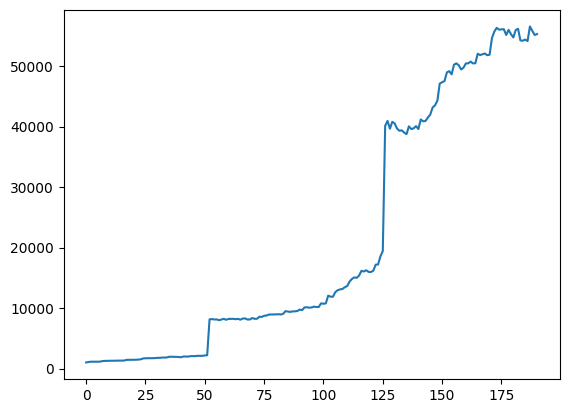

In [54]:
plt.plot(cum_wlth_mn_110_1m_c_mn_90_1m_p)

In [55]:
mn_90_3m_p = gen_options_pnl(moneyness=90, time_to_expiry=3,callput='p')

Data with moneyness=90,p and expiry in 3 months not traded on 20100226
Data with moneyness=90,p and expiry in 3 months not traded on 20100528
Data with moneyness=90,p and expiry in 3 months not traded on 20100831


In [56]:
mn_110_3m_c = gen_options_pnl(moneyness=110, time_to_expiry=3,callput='c')

Data with moneyness=110,c and expiry in 3 months not traded on 20100226
Data with moneyness=110,c and expiry in 3 months not traded on 20100528
Data with moneyness=110,c and expiry in 3 months not traded on 20100831


In [57]:
with pd.ExcelWriter(os.path.join(saving_dir,'1m_110c_90p.xlsx'), engine="xlsxwriter") as writer:
    mn_90_1m_p.to_excel(writer, sheet_name="mn_90_1m_p", index=False)
    mn_110_1m_c.to_excel(writer, sheet_name="mn_110_1m_c", index=False)

In [58]:
cum_wlth_mn_110_3m_c_mn_90_3m_p = 1000*(1 + mn_110_3m_c['OptPnl']+mn_90_3m_p['OptPnl']).cumprod()

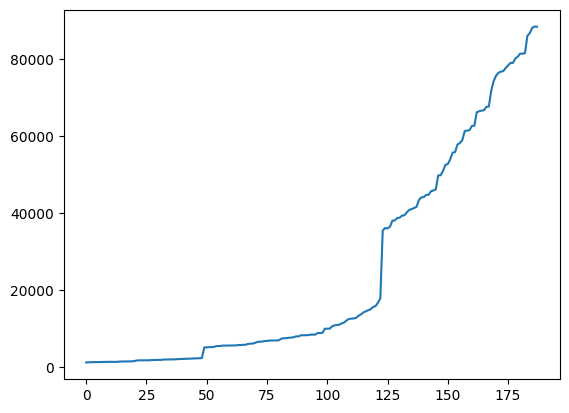

In [59]:
plt.plot(cum_wlth_mn_110_3m_c_mn_90_3m_p)

In [60]:
with pd.ExcelWriter(os.path.join(saving_dir,'3m_110c_90p.xlsx'), engine="xlsxwriter") as writer:
    mn_90_3m_p.to_excel(writer, sheet_name="mn_90_3m_p", index=False)
    mn_110_3m_c.to_excel(writer, sheet_name="mn_110_3m_c", index=False)

In [61]:
dates = np.sort(df[df.Symbol == 'EV'].TradeDate.unique())
len(dates)

192